# DTEx213. Multi-Particle Tracking

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx213_multi_particle_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

In this example, you train a U-Net on simulated data to detect and localize quantum dots, and then apply it to experimental fluorescence microscopy images.

In [2]:
import os

import deeplay as dl
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import torch

from PIL import Image, ImageSequence

## 1. Downloading the Dataset

The dataset consists of fluorescence microscopy images of quantum dots inside membrane proteins of living cells.

First, you write a function to download the dataset from Google Drive.

In [3]:
def download_file_from_google_drive(file_id, root):
    """Download file from Google Drive."""

    try:
        import gdown
    except ModuleNotFoundError:
        raise RuntimeError(
            "To download files from GDrive, 'gdown' is required. "
            "You can install it with 'pip install gdown'."
        )

    root = os.path.expanduser(root)
    filename = file_id + ".zip"
    fpath = os.fspath(os.path.join(root, filename))

    os.makedirs(root, exist_ok=True)

    gdown.download(id=file_id, output=fpath, quiet=False)

    return fpath

Then you set the dataset id and folder name.

In [4]:
dataset_id = "1naaoxIaAU1F_rBaI-I1pB1K4Sp6pq_Jv"
folder_name = "QuantumDots"

You create a `datasets` folder if it does not exist.

In [5]:
if not os.path.exists("datasets"):
    os.mkdir("datasets")

dataset_path = f"datasets/{folder_name}"

Finally, you download and extract the dataset.

In [6]:
# Skip if dataset already exists and has content.
if os.path.exists(dataset_path) and os.listdir(dataset_path):
    print("Dataset already downloaded.")
else:
    import zipfile

    # Make dataset folder if missing.
    if not os.path.exists(dataset_path):
        os.mkdir(dataset_path)

    # Download zip file.
    print(f"Downloading {folder_name}...")
    fpath = download_file_from_google_drive(dataset_id, "datasets")

    # Extract zip file.
    print(f"Extracting {folder_name}...")
    with zipfile.ZipFile(fpath, "r") as zip_ref:
        zip_ref.extractall("datasets")

    # Delete zip file.
    os.remove(fpath)

    # Fix nested folder case.
    nested = f"{dataset_path}/{folder_name}"
    if os.path.isdir(nested) and not os.listdir(dataset_path):
        os.rename(nested, dataset_path)

Dataset already downloaded.


With the dataset downloaded, you read in the images and display one example. These are the experimental frames you will apply the trained model to later, and the ones your simulated training images should resemble.

In [7]:
def load_tif_stack(path):
    """Load a multi-frame TIFF as a (frames, height, width) array."""
    with Image.open(path) as img:
        return np.stack(
            [np.array(frame) for frame in ImageSequence.Iterator(img)]
        )


images = load_tif_stack("./datasets/QuantumDots/Qdots.tif")

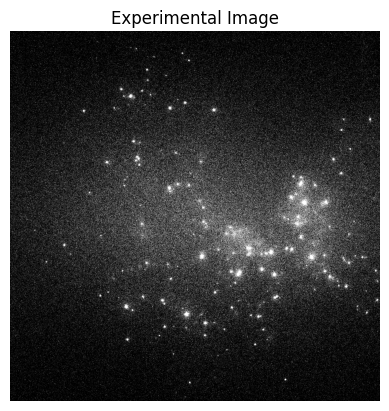

In [ ]:
vmin, vmax = np.percentile(images[100], [50, 99])
plt.imshow(images[100], cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Experimental Image")
plt.axis("off")
plt.show();

## 2. Defining the Training Set

There are no ground-truth labels for the experimental images, so instead you train the network on simulated images, where you know exactly where every particle is. In this section you build a pipeline that generates simulated images together with their labels.

### 2.1. Defining the Pipeline for the Simulated Images

The training set consists of simulated 128 by 128 pixel images, each containing multiple particles. You simulate each particle as a point scatterer, with a position drawn uniformly across the image plane, a position along the axis normal to the camera drawn from a normal distribution with a standard deviation of 5 pixels, and an intensity between 1 and 10. Each image contains from 10 to 19 particles.

In [ ]:
image_size = 128

particle = dt.PointParticle(
    position=lambda: np.random.rand(2) * image_size,
    z=lambda: np.random.randn() * 5,
    intensity=lambda: 1 + np.random.rand() * 9,
    position_unit="pixel",
)

number_of_particles = lambda: np.random.randint(10, 20)

particles = particle ^ number_of_particles

You image the particles with a fluorescence microscope with a numerical aperture between 0.6 and 0.8, an illuminating laser wavelength of 500 nm, and a magnification of 10.

In [ ]:
optics = dt.Fluorescence(
    NA=lambda: 0.6 + np.random.rand() * 0.2,
    wavelength=500e-9,
    resolution=1e-6,
    magnification=10,
    output_region=(0, 0, image_size, image_size),
)

imaged_particles = optics(particles)

You define two more steps: a normalization that rescales each image to lie between two random numbers within (0, 1), and Poisson noise with a signal-to-noise ratio between 4 and 7. You then chain them after the microscope to produce the simulated images.

In [11]:
normalization = dt.NormalizeMinMax(
    min=lambda: np.random.rand() * 0.4,
    max=lambda min: min + 0.1 + np.random.rand() * 0.5,
)
noise = dt.Poisson(
    snr=lambda: 4 + np.random.rand() * 3, background=normalization.min
)

simulated_particles = dt.Value(imaged_particles) >> normalization >> noise

### 2.2. Defining the Training Labels

The label for each image is a segmentation mask marking where the particles are. You build it with `dt.SampleToMasks`, which turns the simulated particles into a binary mask, then convert it to integers and one-hot encode it into two classes: background and particle.

In [12]:
get_masks = (
    particles
    >> dt.SampleToMasks(
        lambda: lambda particle: particle > 0,
        output_region=optics.output_region,
        merge_method="or",
    )
    >> dt.AsType("int")
    >> dt.OneHot(num_classes=2)
)

### 2.3. Combining the Simulation and Label Pipelines

You combine the image and label pipelines with `&`, move the channel axis to the front, and convert the result to a PyTorch tensor. Each sample is then an image paired with its mask, ready for training.

In [13]:
pipeline = (
    (simulated_particles & get_masks)
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float)
)

### 2.4. Visualizing the Training Data

To check the pipeline, you generate and display a few simulated images next to their masks.

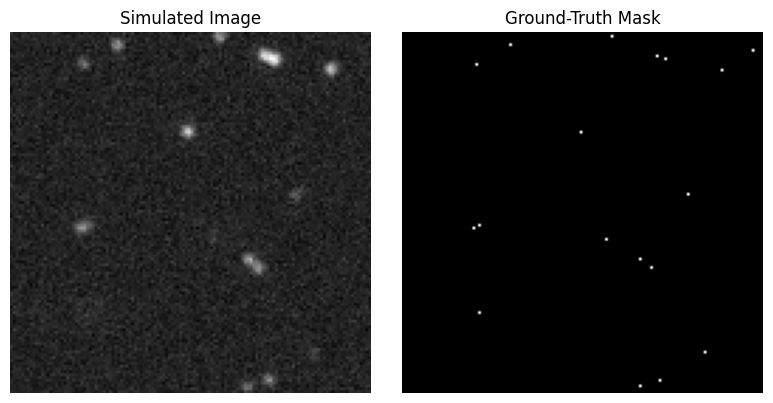

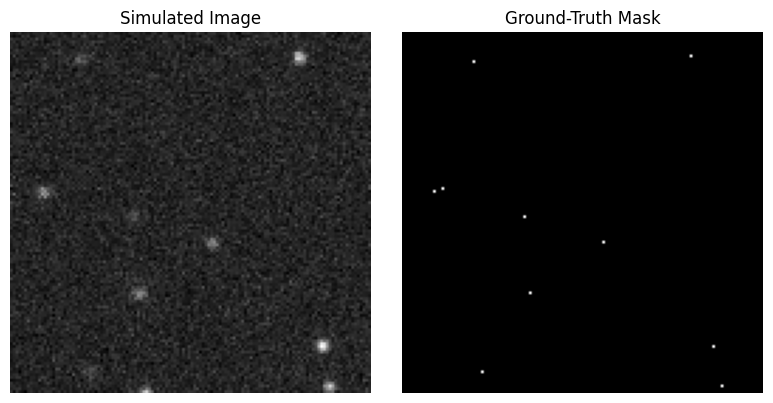

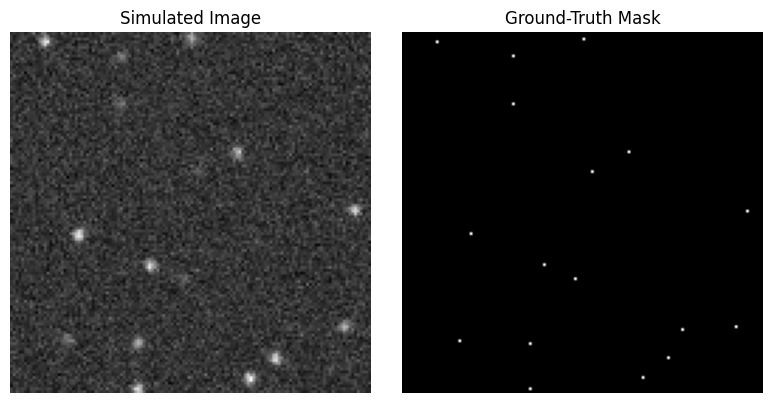

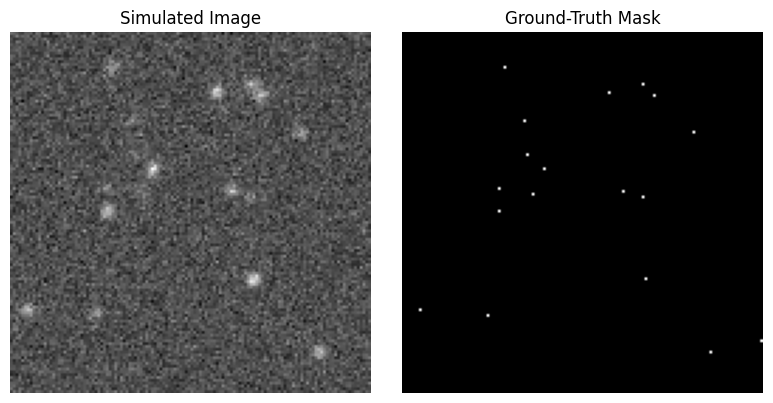

In [14]:
number_of_images = 4

for _ in range(number_of_images):
    image, labels = pipeline.update().resolve()

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image[0, ...], cmap="gray")
    plt.title("Simulated Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(labels[1], cmap="gray")
    plt.title("Ground-Truth Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 3. Defining the Network

The network is a U-Net, implemented with `deeplay`, that outputs two classes: background and particle. You build it as a regressor with the Adam optimizer and a weighted cross-entropy loss that counts the rare particle pixels more heavily than the background.

In [15]:
model = dl.UNet2d(in_channels=None, encoder_channels=[32, 64], out_channels=2)

unet_regressor = dl.Regressor(
    model=model,
    loss=torch.nn.CrossEntropyLoss(weight=torch.tensor([1, 10])),
    optimizer=dl.Adam(lr=1e-3),
).build()

print(unet_regressor)

Regressor(
  (loss): CrossEntropyLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
      (postprocess): Identity()
    )
    (bottleneck): ConvolutionalNeuralNetwork(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(64, 64,

## 4. Training the Network

The simulation pipeline is wrapped in a dataset and data loader. The `replace=0.1` option regenerates a tenth of the simulated images each epoch, which adds variety without resimulating everything.

In [16]:
dataset = dt.pytorch.Dataset(pipeline, length=128, replace=0.1)
dataloader = dl.DataLoader(dataset, batch_size=4)

You then train the U-Net for 100 epochs, and plot the training history at the end to follow the loss.

C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
C:\Users\xgrmir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:454: A layer with UninitializedParameter was found. Thus, the total number of parameters detected may be inaccurate.

  | Name          | Type             | Params
---------------------------------------------------
0 | loss          | CrossEntropyLoss | 0     
1 | train_metrics | MetricCollection | 0     
2 | val_metrics   | MetricCollection | 0     
3 | test_metrics  | MetricCollection | 0     
4 | model         | UNet2d           | 114 K 
5 | optimizer     | Adam             | 0     
-------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

(<Figure size 1500x500 with 1 Axes>,
 array([[<Axes: title={'center': 'Loss'}, xlabel='Step'>]], dtype=object))

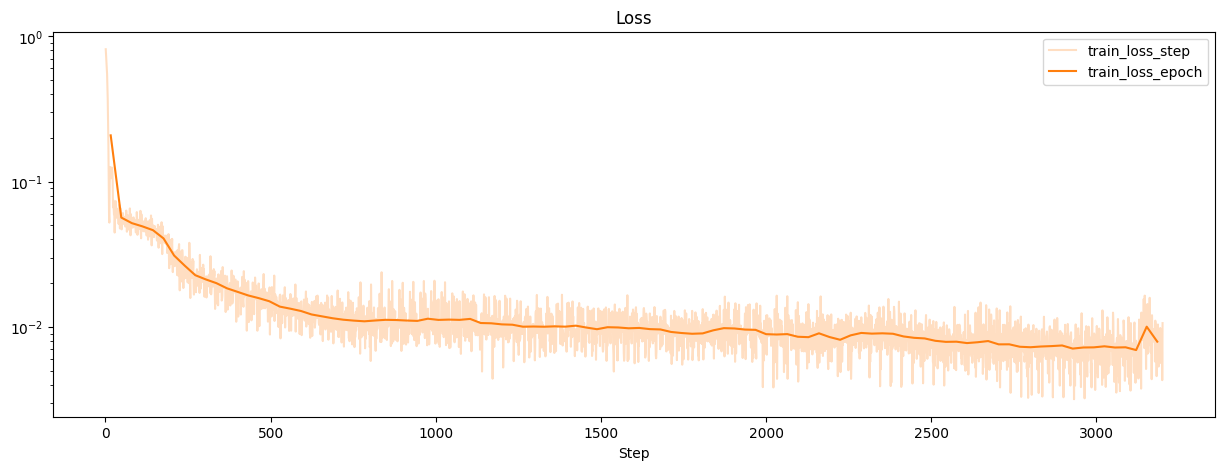

In [17]:
unet_trainer = dl.Trainer(max_epochs=100, accelerator="auto")
unet_trainer.fit(unet_regressor, dataloader)

unet_trainer.history.plot()

## 5. Evaluating the Network

### 5.1. Prediction Visualization

A few simulated images are shown next to their ground-truth masks and the network's predictions.

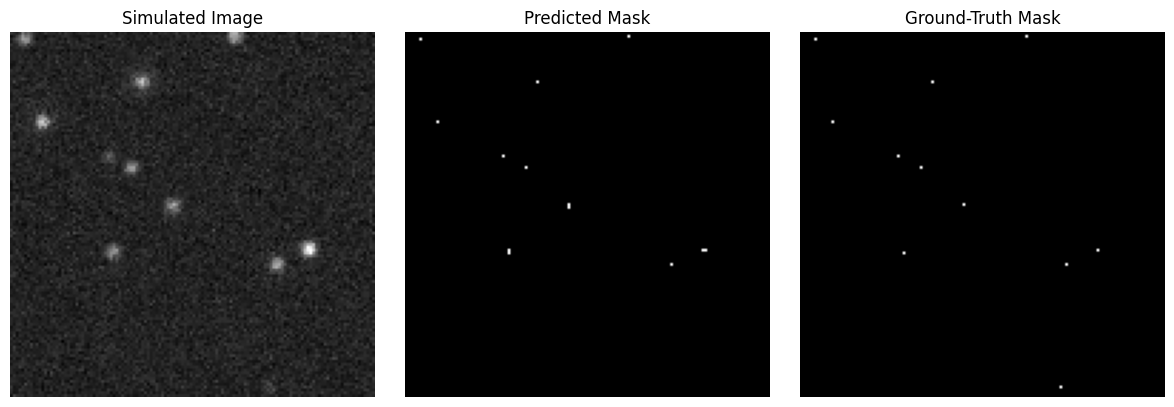

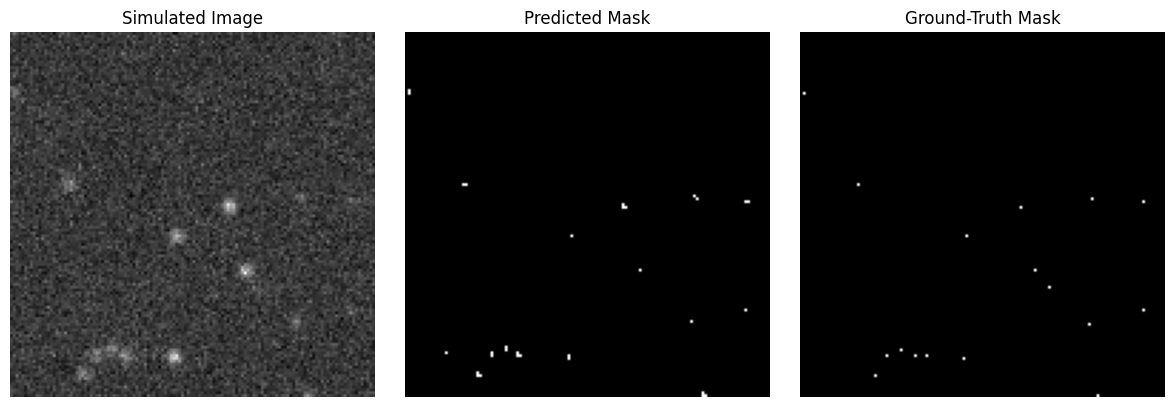

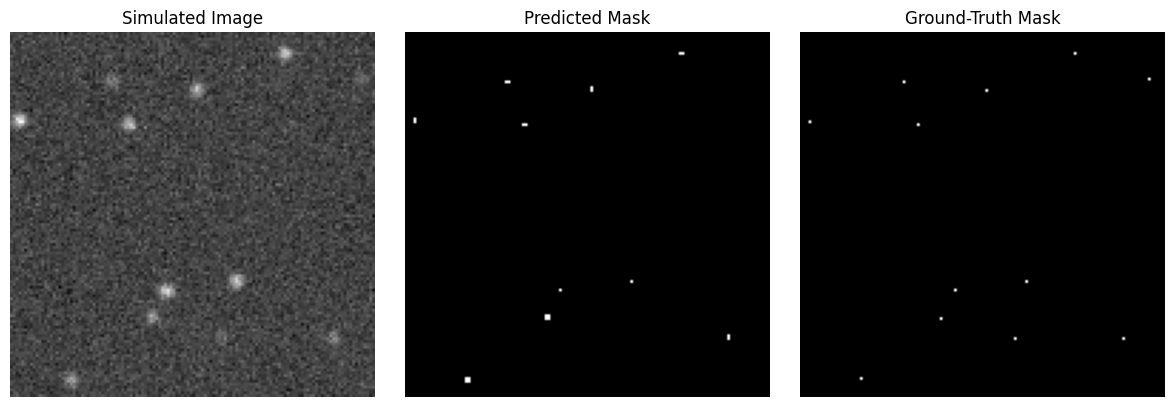

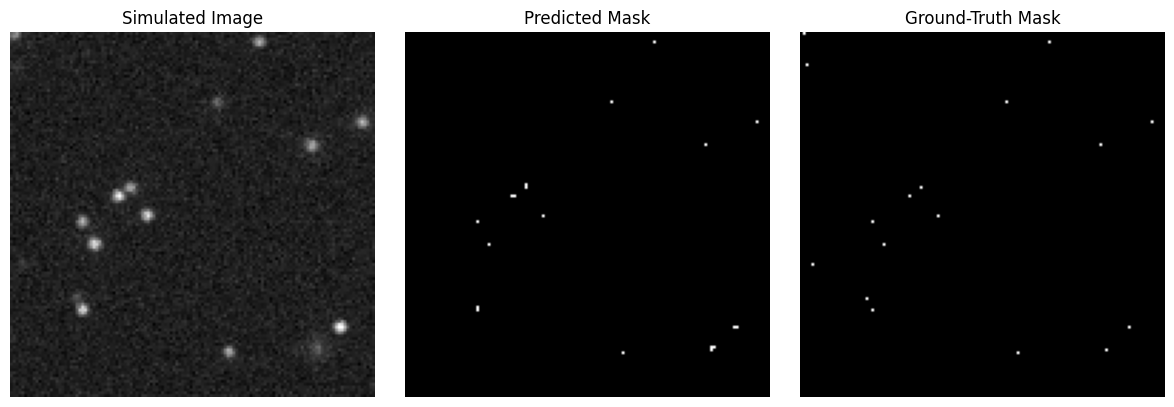

In [18]:
number_of_images = 4

for _ in range(number_of_images):
    plt.figure(figsize=(12, 4))
    
    image, labels = pipeline.update().resolve()

    predicted_mask = model(image.unsqueeze(0))

    plt.subplot(1, 3, 1)
    plt.imshow(image.squeeze(0), cmap="gray")
    plt.title("Simulated Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask[0, 1, ...] > 0.5, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(labels[1], cmap="gray")
    plt.title("Ground-Truth Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### 5.2. Experimental Data

Finally, the trained model is applied to the real quantum dot images, and its detections are overlaid on a few random frames. The network was trained only on simulated images, so this shows how well it carries over to real data.

In [19]:
# Helper function to obtain detections.
def mask_to_positions(mask):
    """Convert binary mask to detections."""
    labels = sk.measure.label(mask)
    props = sk.measure.regionprops(labels)
    return np.array([prop.centroid for prop in props])

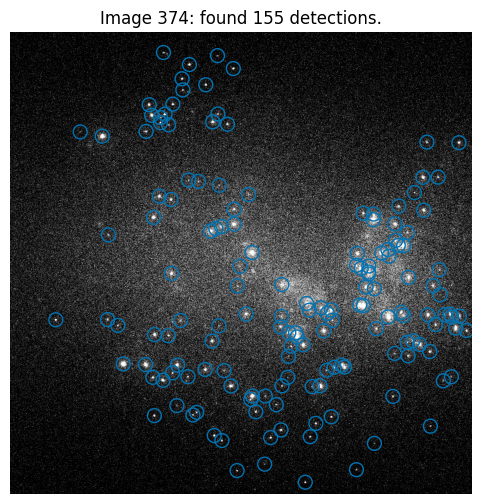

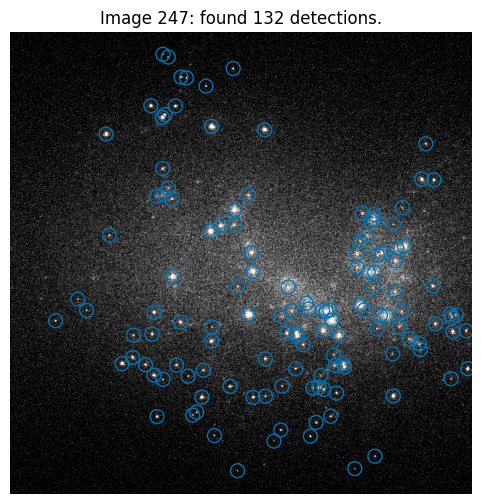

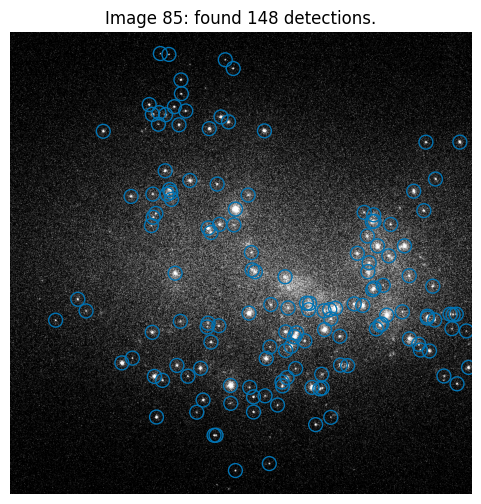

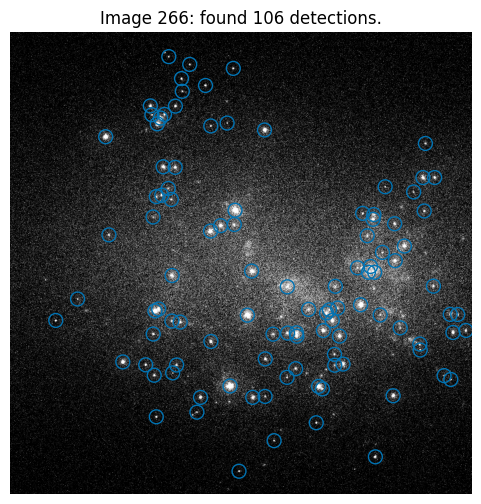

In [25]:
num_samples = 4
indices = np.random.choice(len(images), num_samples, replace=False)

detection_threshold = 0.5

for idx in indices:

    # Convert image to tensor
    image = (
        torch.from_numpy(images[idx].astype(float))
        .unsqueeze(0)
        .unsqueeze(0)
        .to(torch.float32)
    )

    # Normalize to [0, 1]
    image = (image - image.min()) / (image.max() - image.min())

    prediction = model(image).detach()
    pred_mask = torch.nn.functional.softmax(prediction, dim=1)
    positions = mask_to_positions(pred_mask[0, 1, ...] > detection_threshold)

    # Contrast scaling for plotting.
    vmin, vmax = np.percentile(image, [50, 99])

    plt.figure(figsize=(6, 6))
    plt.imshow(image[0, 0, ...], vmin=vmin, vmax=vmax, cmap="gray")

    if positions.shape[0] > 0:
        plt.scatter(
            positions[:, 1],
            positions[:, 0],
            s=100,
            facecolors="none",
            edgecolors=(0.0039, 0.45, 0.70),
        )

    plt.title(f"Image {idx}: found {len(positions[:, 1])} detections.")
    plt.axis("off")
    plt.show()